# Phase 4B — validation-only training-recipe screening

This notebook preserves the preliminary MLP screen and performs the definitive 20-configuration StaticGNN factorial over the five frozen Phase-4A weight/bias pairs, two learning rates, and two hidden dimensions. Both stages use development seed `42` and `nfv3_extended`. Checkpoints are selected by validation average precision and thresholds are selected on validation with `max_f1`. The notebook never loads `test1` or `test2`; verified completed configurations are resumable and are not retrained on a normal rerun.

In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys

REPO_ROOT = Path('/content/temporalgnn-nids')
REPO_URL = 'https://github.com/tatipar/temporalgnn-nids.git'
BRANCH = 'feat/fair-retrain-clean'

if REPO_ROOT.exists():
    subprocess.run(['git', '-C', str(REPO_ROOT), 'fetch', 'origin', BRANCH], check=True)
    subprocess.run(['git', '-C', str(REPO_ROOT), 'switch', BRANCH], check=True)
    subprocess.run(['git', '-C', str(REPO_ROOT), 'pull', '--ff-only', 'origin', BRANCH], check=True)
else:
    subprocess.run(
        ['git', 'clone', '--branch', BRANCH, '--single-branch', REPO_URL, str(REPO_ROOT)],
        check=True,
    )
sys.path.insert(0, str(REPO_ROOT / 'code/python'))

In [2]:
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'torch-geometric'], check=True)

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
GRAPH_VERSION = 'infiltration_v1_w30_tcpflags_episode_split_v1'
DRIVE_ROOT = Path('/content/drive/MyDrive/nids-fair-retrain')
GRAPH_ROOT = DRIVE_ROOT / 'graphs' / GRAPH_VERSION
CALIBRATION_MANIFEST = DRIVE_ROOT / 'calibration' / GRAPH_VERSION / 'calibration_manifest.json'
RESULTS_ROOT = DRIVE_ROOT / 'phase4b' / GRAPH_VERSION

MLP_EPOCHS = 60
MLP_HIDDEN_DIM = 64
MLP_NODE_DIM = 32
DROPOUT = 0.2
MLP_LEARNING_RATE = 1e-3
BATCH_STEPS = 10
PATIENCE = 10
MIN_DELTA = 1e-4
AP_EQUIVALENCE_MARGIN = 0.005
NUM_WORKERS = 2
MLP_DEVICE = 'auto'
VERIFY_GRAPH_CHECKSUMS = False
RUN_PRELIMINARY_MLP = False

assert (GRAPH_ROOT / 'graph_manifest.json').is_file(), GRAPH_ROOT
assert CALIBRATION_MANIFEST.is_file(), CALIBRATION_MANIFEST
print({
    'graph_root': str(GRAPH_ROOT),
    'calibration_manifest': str(CALIBRATION_MANIFEST),
    'results_root': str(RESULTS_ROOT),
})

{'graph_root': '/content/drive/MyDrive/nids-fair-retrain/graphs/infiltration_v1_w30_tcpflags_episode_split_v1', 'calibration_manifest': '/content/drive/MyDrive/nids-fair-retrain/calibration/infiltration_v1_w30_tcpflags_episode_split_v1/calibration_manifest.json', 'results_root': '/content/drive/MyDrive/nids-fair-retrain/phase4b/infiltration_v1_w30_tcpflags_episode_split_v1'}


## Acceptance tests

Run the complete suite against the exact revision before starting expensive screening.

In [4]:
test_env = dict(os.environ)
test_env['PYTHONPATH'] = str(REPO_ROOT / 'code/python')
subprocess.run(
    [
        sys.executable, '-m', 'unittest', 'discover',
        '-s', str(REPO_ROOT / 'code/python/tests'), '-p', 'test_*.py', '-v',
    ],
    cwd=REPO_ROOT,
    env=test_env,
    check=True,
)

CompletedProcess(args=['/usr/bin/python3', '-m', 'unittest', 'discover', '-s', '/content/temporalgnn-nids/code/python/tests', '-p', 'test_*.py', '-v'], returncode=0)

## Stage 1 — archived preliminary SimpleMLP screen

These cells preserve and inspect the completed preliminary run. `RUN_PRELIMINARY_MLP` is false by default because the frozen MLP plan belongs to its original code revision and should not be regenerated while running the StaticGNN factorial.

In [6]:
base_command = [
    sys.executable,
    str(REPO_ROOT / 'code/python/scripts/screen_calibration.py'),
    '--graph-root', str(GRAPH_ROOT),
    '--calibration-manifest', str(CALIBRATION_MANIFEST),
    '--results-root', str(RESULTS_ROOT),
    '--epochs', str(MLP_EPOCHS),
    '--hidden-dim', str(MLP_HIDDEN_DIM),
    '--node-dim', str(MLP_NODE_DIM),
    '--dropout', str(DROPOUT),
    '--learning-rate', str(MLP_LEARNING_RATE),
    '--batch-steps', str(BATCH_STEPS),
    '--patience', str(PATIENCE),
    '--min-delta', str(MIN_DELTA),
    '--ap-equivalence-margin', str(AP_EQUIVALENCE_MARGIN),
    '--num-workers', str(NUM_WORKERS),
    '--device', MLP_DEVICE,
]
if VERIFY_GRAPH_CHECKSUMS:
    base_command.append('--verify-checksums')

if RUN_PRELIMINARY_MLP:
    subprocess.run(base_command + ['--stage', 'mlp', '--plan-only'], cwd=REPO_ROOT, check=True)
else:
    print('Skipping the archived preliminary MLP plan.')

CompletedProcess(args=['/usr/bin/python3', '/content/temporalgnn-nids/code/python/scripts/screen_calibration.py', '--graph-root', '/content/drive/MyDrive/nids-fair-retrain/graphs/infiltration_v1_w30_tcpflags_episode_split_v1', '--calibration-manifest', '/content/drive/MyDrive/nids-fair-retrain/calibration/infiltration_v1_w30_tcpflags_episode_split_v1/calibration_manifest.json', '--results-root', '/content/drive/MyDrive/nids-fair-retrain/phase4b/infiltration_v1_w30_tcpflags_episode_split_v1', '--epochs', '60', '--hidden-dim', '64', '--node-dim', '32', '--dropout', '0.2', '--learning-rate', '0.001', '--batch-steps', '10', '--patience', '10', '--min-delta', '0.0001', '--ap-equivalence-margin', '0.005', '--num-workers', '2', '--device', 'auto', '--stage', 'mlp', '--plan-only'], returncode=0)

In [7]:
mlp_plan_path = RESULTS_ROOT / 'mlp' / 'screening_plan.json'
mlp_plan = json.loads(mlp_plan_path.read_text(encoding='utf-8'))
print(json.dumps({
    'stage': mlp_plan['stage'],
    'seed': mlp_plan['seed'],
    'feature_profile': mlp_plan['feature_profile'],
    'selection_policy': mlp_plan['selection_policy'],
    'execution': mlp_plan['execution'],
    'candidate_ids': [item['candidate_id'] for item in mlp_plan['configurations']],
}, indent=2))

{
  "stage": "mlp",
  "seed": 42,
  "feature_profile": "nfv3_extended",
  "selection_policy": {
    "checkpoint_metric": "validation_average_precision",
    "checkpoint_mode": "max",
    "fixed_0_5_comparison_prohibited": true,
    "practical_ap_equivalence_margin_absolute": 0.005,
    "preference_inside_margin": "smaller pos_weight",
    "shortlist_rule": "include every candidate with validation AP >= best validation AP minus the frozen absolute margin",
    "test_splits_accessed": false,
    "threshold_split": "validation",
    "threshold_strategy": "max_f1"
  },
  "execution": {
    "batch_size_graphs": 1,
    "device": "cpu",
    "num_workers": 2,
    "shuffle": false
  },
  "candidate_ids": [
    "calibration_01",
    "calibration_02",
    "calibration_03",
    "calibration_04",
    "calibration_05"
  ]
}


In [8]:
# This remains available only to resume the original preliminary run.
if RUN_PRELIMINARY_MLP:
    subprocess.run(base_command + ['--stage', 'mlp'], cwd=REPO_ROOT, check=True)
else:
    print('Skipping the archived preliminary MLP training run.')

CompletedProcess(args=['/usr/bin/python3', '/content/temporalgnn-nids/code/python/scripts/screen_calibration.py', '--graph-root', '/content/drive/MyDrive/nids-fair-retrain/graphs/infiltration_v1_w30_tcpflags_episode_split_v1', '--calibration-manifest', '/content/drive/MyDrive/nids-fair-retrain/calibration/infiltration_v1_w30_tcpflags_episode_split_v1/calibration_manifest.json', '--results-root', '/content/drive/MyDrive/nids-fair-retrain/phase4b/infiltration_v1_w30_tcpflags_episode_split_v1', '--epochs', '60', '--hidden-dim', '64', '--node-dim', '32', '--dropout', '0.2', '--learning-rate', '0.001', '--batch-steps', '10', '--patience', '10', '--min-delta', '0.0001', '--ap-equivalence-margin', '0.005', '--num-workers', '2', '--device', 'auto', '--stage', 'mlp'], returncode=0)

In [4]:
import pandas as pd
from IPython.display import display

mlp_summary_path = RESULTS_ROOT / 'mlp' / 'screening_summary.json'
mlp_summary = json.loads(mlp_summary_path.read_text(encoding='utf-8'))
assert mlp_summary['status'] == 'complete', mlp_summary['missing_candidate_ids']
mlp_table = pd.DataFrame(mlp_summary['ranking'])
display(mlp_table[[
    'candidate_id', 'pos_weight', 'output_bias_init',
    'best_validation_ap', 'best_epoch', 'stopped_epoch',
    'selected_validation_threshold',
]])
print(json.dumps(mlp_summary['ranking_policy'], indent=2))
print('Recommended ST-GNN shortlist:', mlp_summary['recommended_stgnn_shortlist_ids'])
print('Preferred smaller-weight candidate:', mlp_summary['preferred_smaller_weight_candidate_id'])

,candidate_id,pos_weight,output_bias_init,best_validation_ap,best_epoch,stopped_epoch,selected_validation_threshold
0,calibration_01,1.000000,-3.359622,0.970291,59,60,0.189086
1,calibration_03,5.364542,-1.679811,0.968827,59,60,0.567660
2,calibration_02,2.000000,-2.666475,0.955945,57,60,0.320733
3,calibration_04,14.389153,-0.693147,0.949994,44,55,0.800797
4,calibration_05,28.778307,0.000000,0.911890,17,28,0.912544


{
  "display_tie_break": "ascending pos_weight",
  "practical_ap_equivalence_margin_absolute": 0.005,
  "preference_inside_margin": "smaller pos_weight",
  "primary": "descending validation average precision",
  "shortlist": "validation AP >= best validation AP minus the frozen margin",
  "test_splits_accessed": false
}
Recommended ST-GNN shortlist: ['calibration_01', 'calibration_03']
Preferred smaller-weight candidate: calibration_01


calibration_01 epochs=60 best_epoch=60 best_AP=0.970291 last_10= [0.812885, 0.95216, 0.959426, 0.817513, 0.942899, 0.805096, 0.811892, 0.816331, 0.817687, 0.970291]
calibration_02 epochs=60 best_epoch=58 best_AP=0.955945 last_10= [0.915865, 0.776235, 0.930446, 0.942763, 0.942145, 0.95361, 0.950813, 0.955945, 0.954904, 0.951377]
calibration_03 epochs=60 best_epoch=60 best_AP=0.968827 last_10= [0.96028, 0.95295, 0.813074, 0.965987, 0.932777, 0.951194, 0.952958, 0.951359, 0.955825, 0.968827]
calibration_04 epochs=55 best_epoch=45 best_AP=0.949994 last_10= [0.940873, 0.930907, 0.939924, 0.940276, 0.943123, 0.942524, 0.809792, 0.94929, 0.94777, 0.944335]
calibration_05 epochs=28 best_epoch=18 best_AP=0.911890 last_10= [0.744732, 0.874525, 0.769375, 0.90388, 0.744832, 0.894702, 0.902996, 0.882536, 0.884295, 0.780423]


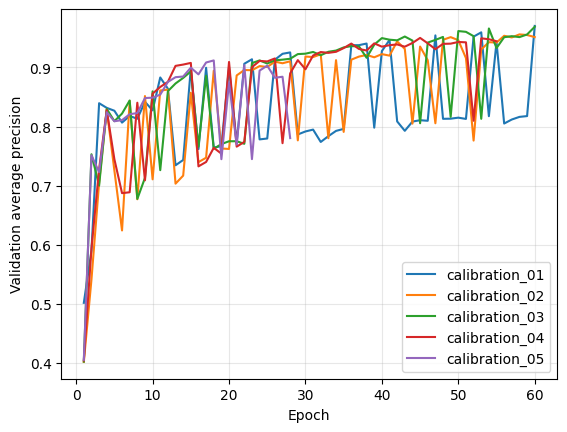

In [5]:
import json
import matplotlib.pyplot as plt

for candidate_id in [
    "calibration_01",
    "calibration_02",
    "calibration_03",
    "calibration_04",
    "calibration_05",
]:
    history_root = RESULTS_ROOT / "mlp" / candidate_id / "histories"
    paths = list(history_root.rglob("training_history_*.json"))
    history_path = max(paths, key=lambda path: path.stat().st_mtime_ns)
    history = json.loads(history_path.read_text(encoding="utf-8"))

    aps = history["training"]["validation_average_precision"]
    best_epoch = history["early_stopping"]["best_epoch"] + 1

    print(
        candidate_id,
        f"epochs={len(aps)}",
        f"best_epoch={best_epoch}",
        f"best_AP={history['early_stopping']['best_score']:.6f}",
        "last_10=",
        [round(value, 6) for value in aps[-10:]],
    )

    plt.plot(range(1, len(aps) + 1), aps, label=candidate_id)

plt.xlabel("Epoch")
plt.ylabel("Validation average precision")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [6]:
import json
import numpy as np

for candidate_id in [
    "calibration_01",
    "calibration_02",
    "calibration_03",
    "calibration_04",
    "calibration_05",
]:
    history_root = RESULTS_ROOT / "mlp" / candidate_id / "histories"
    paths = list(history_root.rglob("training_history_*.json"))
    history_path = max(paths, key=lambda path: path.stat().st_mtime_ns)
    history = json.loads(history_path.read_text(encoding="utf-8"))

    training = history["training"]
    aps = np.asarray(training["validation_average_precision"], dtype=float)
    train_loss = np.asarray(training["train_loss_per_flow"], dtype=float)
    val_loss = np.asarray(training["validation_loss_per_flow"], dtype=float)
    gradients = np.asarray(
        [
            value
            for value in training["gradient_norm_max"]
            if value is not None
        ],
        dtype=float,
    )

    tail = aps[-10:]

    print(f"\n{candidate_id}")
    print(
        "AP last 10:",
        f"mean={tail.mean():.6f}",
        f"std={tail.std():.6f}",
        f"min={tail.min():.6f}",
        f"max={tail.max():.6f}",
    )
    print(
        "Train loss:",
        f"first={train_loss[0]:.6f}",
        f"last={train_loss[-1]:.6f}",
        f"min={train_loss.min():.6f}",
    )
    print(
        "Validation loss:",
        f"last={val_loss[-1]:.6f}",
        f"last10_std={val_loss[-10:].std():.6f}",
        f"min={val_loss.min():.6f}",
    )
    print(
        "Gradient norm:",
        f"median={np.median(gradients):.6f}",
        f"max={gradients.max():.6f}",
        f"last={gradients[-1]:.6f}",
    )




calibration_01
AP last 10: mean=0.870618 std=0.070242 min=0.805096 max=0.970291
Train loss: first=0.216543 last=0.045214 min=0.045214
Validation loss: last=0.048971 last10_std=0.001207 min=0.048435
Gradient norm: median=1.006470 max=4.067183 last=0.775617

calibration_02
AP last 10: mean=0.927410 std=0.051796 min=0.776235 max=0.955945
Train loss: first=0.387856 last=0.067296 min=0.066784
Validation loss: last=0.070999 last10_std=0.002808 min=0.069737
Gradient norm: median=1.778258 max=8.251325 last=1.424738

calibration_03
AP last 10: mean=0.940523 std=0.043494 min=0.813074 max=0.968827
Train loss: first=0.868317 last=0.098660 min=0.098528
Validation loss: last=0.101250 last10_std=0.003341 min=0.096659
Gradient norm: median=3.595376 max=29.451292 last=2.667016

calibration_04
AP last 10: mean=0.928882 std=0.039979 min=0.809792 max=0.949290
Train loss: first=1.886776 last=0.140201 min=0.132569
Validation loss: last=0.131754 last10_std=0.003029 min=0.124424
Gradient norm: median=5.92916

## Stage 2 — corrected StaticGNN factorial

The MLP run above is retained as preliminary evidence. Final calibration screening now uses StaticGNN as the architecture-neutral reference: all five frozen weight/bias pairs are crossed with learning rates `[0.001, 0.005]` and hidden dimensions `[32, 64]`, for 20 seed-42 configurations. StaticGNN retains the historically used node projection dimension 16 and raises only the early-stopped maximum to 100 epochs to avoid censoring configurations that are still improving at epoch 60. Before planning, this cell copies only train and validation graphs to checksum-verified local Colab storage. The script writes a frozen plan and supports exact epoch-boundary resume. CPU is explicit to protect the Colab GPU quota.

In [ ]:
import hashlib
import shutil

STATIC_SOURCE_GRAPH_ROOT = GRAPH_ROOT
STATIC_GRAPH_ROOT = Path('/content/nids-fair-retrain/graphs') / GRAPH_VERSION
STATIC_PROFILE = 'nfv3_extended'
STATIC_SPLITS = ('train', 'val')
LOCAL_DISK_RESERVE_BYTES = 10 * 1024**3


def sha256_path(path):
    digest = hashlib.sha256()
    with path.open('rb') as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()


checksum_index = json.loads(
    (STATIC_SOURCE_GRAPH_ROOT / 'artifact_checksums.json').read_text(encoding='utf-8')
)
profile_records = checksum_index['graphs'][STATIC_PROFILE]


def is_requested_graph(relative_path):
    parts = Path(relative_path).parts
    return len(parts) >= 3 and parts[0] == STATIC_PROFILE and parts[1] in STATIC_SPLITS


selected_records = {
    relative_path: record
    for relative_path, record in profile_records.items()
    if is_requested_graph(relative_path)
}
selected_split_names = {Path(path).parts[1] for path in selected_records}
if selected_split_names != set(STATIC_SPLITS):
    raise RuntimeError('The checksum index does not contain both requested graph splits.')
required_bytes = sum(int(record['bytes']) for record in selected_records.values())
missing_bytes = sum(
    int(record['bytes'])
    for relative_path, record in selected_records.items()
    if not (STATIC_GRAPH_ROOT / relative_path).is_file()
    or (STATIC_GRAPH_ROOT / relative_path).stat().st_size != int(record['bytes'])
)
free_bytes = shutil.disk_usage('/content').free
disk_preflight = {
    'required_gib': round(required_bytes / 1024**3, 2),
    'missing_gib': round(missing_bytes / 1024**3, 2),
    'free_gib': round(free_bytes / 1024**3, 2),
    'reserved_gib': round(LOCAL_DISK_RESERVE_BYTES / 1024**3, 2),
    'copy_is_safe': missing_bytes + LOCAL_DISK_RESERVE_BYTES <= free_bytes,
}
print(disk_preflight)
if not disk_preflight['copy_is_safe']:
    raise RuntimeError('Insufficient local Colab storage for the train/validation graph cache.')

metadata_paths = [
    Path('graph_manifest.json'),
    Path('artifact_checksums.json'),
    Path(STATIC_PROFILE) / 'feature_schema.json',
    Path(STATIC_PROFILE) / 'scaler.joblib',
]
for relative_path in metadata_paths:
    source = STATIC_SOURCE_GRAPH_ROOT / relative_path
    destination = STATIC_GRAPH_ROOT / relative_path
    destination.parent.mkdir(parents=True, exist_ok=True)
    if (
        not destination.is_file()
        or destination.stat().st_size != source.stat().st_size
        or sha256_path(destination) != sha256_path(source)
    ):
        shutil.copy2(source, destination)

copied_graphs = 0
for index, (relative_path, record) in enumerate(sorted(selected_records.items()), start=1):
    source = STATIC_SOURCE_GRAPH_ROOT / relative_path
    destination = STATIC_GRAPH_ROOT / relative_path
    destination.parent.mkdir(parents=True, exist_ok=True)
    expected_bytes = int(record['bytes'])
    expected_sha256 = record['sha256']
    destination_is_valid = (
        destination.is_file()
        and destination.stat().st_size == expected_bytes
        and sha256_path(destination) == expected_sha256
    )
    if not destination_is_valid:
        shutil.copy2(source, destination)
        copied_graphs += 1
    if destination.stat().st_size != expected_bytes or sha256_path(destination) != expected_sha256:
        raise RuntimeError(f'Local graph verification failed: {destination}')
    if index % 100 == 0 or index == len(selected_records):
        print(f'Local graph cache: verified {index}/{len(selected_records)} files')

if sha256_path(STATIC_GRAPH_ROOT / 'graph_manifest.json') != sha256_path(
    STATIC_SOURCE_GRAPH_ROOT / 'graph_manifest.json'
):
    raise RuntimeError('The local and Drive graph manifests differ.')
print({
    'source_graph_root': str(STATIC_SOURCE_GRAPH_ROOT),
    'local_graph_root': str(STATIC_GRAPH_ROOT),
    'copied_graphs': copied_graphs,
    'verified_graphs': len(selected_records),
    'splits': STATIC_SPLITS,
})

STATIC_MAX_EPOCHS = 100
STATIC_NODE_DIM = 16
STATIC_LEARNING_RATES = (0.001, 0.005)
STATIC_HIDDEN_DIMS = (32, 64)
STATIC_FACTORIAL_DEVICE = 'cpu'
STATIC_LOCAL_RESUME_ROOT = (
    Path('/content/nids-fair-retrain/resume') / GRAPH_VERSION / 'staticgnn_factorial'
)
STATIC_RESUME_LOCAL_EVERY_EPOCHS = 10
STATIC_RESUME_SYNC_MINUTES = 60

factorial_command = [
    sys.executable, '-u',
    str(REPO_ROOT / 'code/python/scripts/screen_staticgnn_factorial.py'),
    '--graph-root', str(STATIC_GRAPH_ROOT),
    '--calibration-manifest', str(CALIBRATION_MANIFEST),
    '--results-root', str(RESULTS_ROOT),
    '--epochs', str(STATIC_MAX_EPOCHS),
    '--node-dim', str(STATIC_NODE_DIM),
    '--dropout', str(DROPOUT),
    '--batch-steps', str(BATCH_STEPS),
    '--patience', str(PATIENCE),
    '--min-delta', str(MIN_DELTA),
    '--ap-equivalence-margin', str(AP_EQUIVALENCE_MARGIN),
    '--num-workers', str(NUM_WORKERS),
    '--device', STATIC_FACTORIAL_DEVICE,
    '--local-resume-root', str(STATIC_LOCAL_RESUME_ROOT),
    '--resume-local-every-epochs', str(STATIC_RESUME_LOCAL_EVERY_EPOCHS),
    '--resume-sync-minutes', str(STATIC_RESUME_SYNC_MINUTES),
]
for learning_rate in STATIC_LEARNING_RATES:
    factorial_command.extend(['--learning-rate', str(learning_rate)])
for hidden_dim in STATIC_HIDDEN_DIMS:
    factorial_command.extend(['--hidden-dim', str(hidden_dim)])
factorial_command.append('--verify-checksums')

factorial_env = dict(os.environ)
factorial_env['PYTHONUNBUFFERED'] = '1'
subprocess.run(
    factorial_command + ['--plan-only'],
    cwd=REPO_ROOT,
    env=factorial_env,
    check=True,
)

In [ ]:
factorial_plan_path = RESULTS_ROOT / 'staticgnn_factorial' / 'factorial_plan.json'
factorial_plan = json.loads(factorial_plan_path.read_text(encoding='utf-8'))
assert factorial_plan['grid']['configuration_count'] == 20
assert factorial_plan['execution']['device'] == 'cpu'
assert factorial_plan['fixed_parameters']['node_dim'] == 16
assert factorial_plan['fixed_parameters']['maximum_epochs'] == 100
assert factorial_plan['execution']['local_resume_every_epochs'] == 10
assert factorial_plan['execution']['durable_resume_sync_minutes'] == 60.0
assert factorial_plan['execution']['graph_reads'] == 'checksum-verified local Colab cache'
assert factorial_plan['selection_policy']['test_splits_accessed'] is False
print(json.dumps({
    'stage': factorial_plan['stage'],
    'seed': factorial_plan['seed'],
    'feature_profile': factorial_plan['feature_profile'],
    'grid': factorial_plan['grid'],
    'fixed_parameters': factorial_plan['fixed_parameters'],
    'selection_policy': factorial_plan['selection_policy'],
    'execution': factorial_plan['execution'],
    'first_configuration_id': factorial_plan['configurations'][0]['configuration_id'],
    'last_configuration_id': factorial_plan['configurations'][-1]['configuration_id'],
}, indent=2))

### Start or resume the long run

The child Python process is unbuffered. A line prefixed with `*` marks a new best validation-AP checkpoint; non-improving progress is printed every tenth epoch. Each completed configuration prints its threshold method, final validation metrics, timing, artifact paths, overall position, and an approximate remaining time. Printing at this frequency has negligible cost compared with graph training. Resume state is updated locally every ten epochs. One durable state file is first written to Drive at epoch ten or after one hour, whichever happens first, then replaced no more than once per hour and once at early stopping. If Colab disconnects, rerun the staging/plan cell and then this cell without `--rerun`; verified completed configurations are skipped and the interrupted configuration resumes from the newest compatible epoch boundary.

In [ ]:
subprocess.run(
    factorial_command,
    cwd=REPO_ROOT,
    env=factorial_env,
    check=True,
)

In [ ]:
factorial_summary_path = RESULTS_ROOT / 'staticgnn_factorial' / 'factorial_summary.json'
factorial_summary = json.loads(factorial_summary_path.read_text(encoding='utf-8'))
assert factorial_summary['status'] == 'complete', factorial_summary['missing_configuration_ids']
factorial_table = pd.DataFrame(factorial_summary['ranking'])
factorial_table['best_epoch_1_based'] = factorial_table['best_epoch'] + 1
factorial_table['total_minutes'] = factorial_table['timing_seconds'].map(
    lambda timing: timing['total'] / 60
)
display(factorial_table[[
    'configuration_id', 'candidate_id', 'pos_weight', 'output_bias_init',
    'learning_rate', 'hidden_dim', 'best_validation_ap',
    'best_epoch_1_based', 'stopped_epoch',
    'selected_validation_threshold', 'threshold_selection', 'total_minutes',
]])
print('Recommended finalists:', factorial_summary['recommended_finalist_configuration_ids'])
print(
    'Cumulative completed-run time (hours):',
    round(factorial_summary['aggregate_completed_run_timing_seconds']['total'] / 3600, 3),
)
print('Summary:', factorial_summary_path)